In [2]:
import numpy as np
import xroms
from glob import glob
import matplotlib.pyplot as plt
import xarray as xr
import warnings
import sys
import xrft
sys.path.append("/homes/metogra/iufarias/FeedbackSubmeso/useful/")
import romspickle
import matplotlib.colors as colors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import datetime
import cmocean as cm
# from dask.diagnostics import ProgressBar
# import dask
# dask.config.set(**{'array.slicing.split_large_chunks': True})
# from dask.distributed import Client, LocalCluster
from matplotlib.gridspec import GridSpec
import matplotlib.patheffects as PathEffects

warnings.filterwarnings("ignore")

import seawater as sw
import matplotlib.gridspec as gridspec

In [3]:
def Dist_Calc(lon,lat):
    'distance between each point in km'
    dx_km=sw.dist(lon=lon,lat=lat)[0]
    dx_dist=np.insert(dx_km,0,0)
    return np.cumsum(dx_dist)

In [4]:
# # client = Client(n_workers=90)
# # # client = Client(cluster)

# client = Client(n_workers=30,processes=True)
# client

## Reading WRF(3D)

In [7]:
# chunks={'time_counter':1}

# varfw=xr.open_mfdataset('/data/pacific/lrenault/SASI/FULL/WRF/wrf_3D_Y2012M05.nc',data_vars='minimal')
# varfw=xr.open_mfdataset('/data/pacific/lrenault/SASI/FULL/WRF/wrf_3D_Y2012M05_DAY.nc',data_vars='minimal')
# varfw=xr.open_mfdataset('/data/pacific/lrenault/SASI/FULL/WRF/wrfout_Y2012M05.nc',data_vars='minimal')
# varfw=xr.open_mfdataset('/data/pacific/lrenault/SASI/FULL/WRF/wrfout_Y2012M04.nc',data_vars='minimal')
# varfw=xr.open_mfdataset('/data/pacific/lrenault/SASI/FULL/WRF/wrfout_Y2011M06.nc',data_vars='minimal')


# varfw=xr.open_mfdataset('/data/pacific/lrenault/SASI/FULL/WRF/wrfout_',data_vars='minimal')
# vartw=xr.open_mfdataset('/data/pacific/lrenault/SASI/SMTH/WRF/wrfout_',data_vars='minimal')
varfw=xr.open_mfdataset('/data/pacific/lrenault/SASI/FULL/WRF/wrf_3D_Y2011M10.nc',data_vars='minimal')
vartw=xr.open_mfdataset('/data/pacific/lrenault/SASI/SMTH/WRF/wrf_3D_Y2011M10.nc',data_vars='minimal')



OSError: no files to open

In [5]:
!rm /homes/metogra/iufarias/.cache/matplotlib/fontlist*

plt.rcParams.update({'font.size': 14})
# plt.rcParams.update({'font.weight': 'bold'})
# plt.rc('font',**{'family':'serif','serif':['Helvetica']})

plt.rcParams['font.family'] = 'sans-serif'
# plt.rcParams['font.sans-serif'] = ['Lucida Grande']
plt.rcParams['font.sans-serif'] = ['Helvetica']
plt.rcParams['axes.linewidth'] = 1.1

plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['mathtext.rm'] = 'Times New Roman'
plt.rcParams['text.usetex'] = True

props = dict(boxstyle='round', facecolor='wheat', alpha=1)


In [6]:
import xesmf as xe
    
def regrid(var, lons, lats, which):
    # rename coords for use with xESMF
    lonkey = [coord for coord in var.coords if "nav_lon" in coord][0]
    latkey = [coord for coord in var.coords if "nav_lat" in coord][0]
    var = var.rename({lonkey: "lon", latkey: "lat"})

    # whether inputs are
    if which == "pairs":
        locstream_out = True
    elif which == "grid":
        locstream_out = False

    # set up for output
    varint = xr.Dataset({"lat": (["y", "x"], lats), "lon": (["y", "x"], lons)})

    # Calculate weights.
    regridder = xe.Regridder(var, varint, "bilinear",  locstream_out=locstream_out)

    # Perform interpolation
    varint = regridder(var, keep_attrs=True)
    return varint, regridder



## Analysis

In [7]:
w_full=varfw.W.compute().isel(x_grid_M=slice(0,220))
t_air_full=varfw.T.compute().isel(x_grid_M=slice(0,220))
sst_full=varfw.SST.compute().isel(x_grid_M=slice(0,220))-273.15


w_smth=vartw.W.compute().isel(x_grid_M=slice(0,220))
t_air_smth=vartw.T.compute().isel(x_grid_M=slice(0,220))
sst_smth=vartw.SST.compute().isel(x_grid_M=slice(0,220))-273.15

In [8]:
u_full_g=varfw.U.compute()
v_full_g=varfw.V.compute()

u_full=((u_full_g[:,:,:,1:] + u_full_g[:,:,:,:-1])/2).isel(x_grid_U=slice(0,220))
v_full=((v_full_g[:,:,1:,:] + v_full_g[:,:,:-1,:])/2).isel(x_grid_V=slice(0,220))


u_smth_g=vartw.U.compute()
v_smth_g=vartw.V.compute()

u_smth=((u_smth_g[:,:,:,1:] + u_smth_g[:,:,:,:-1])/2).isel(x_grid_U=slice(0,220))
v_smth=((v_smth_g[:,:,1:,:] + v_smth_g[:,:,:-1,:])/2).isel(x_grid_V=slice(0,220))

In [9]:
lat_rho=w_full['nav_lat_grid_M']
lon_rho=w_full['nav_lon_grid_M']

### Instantaneous plots

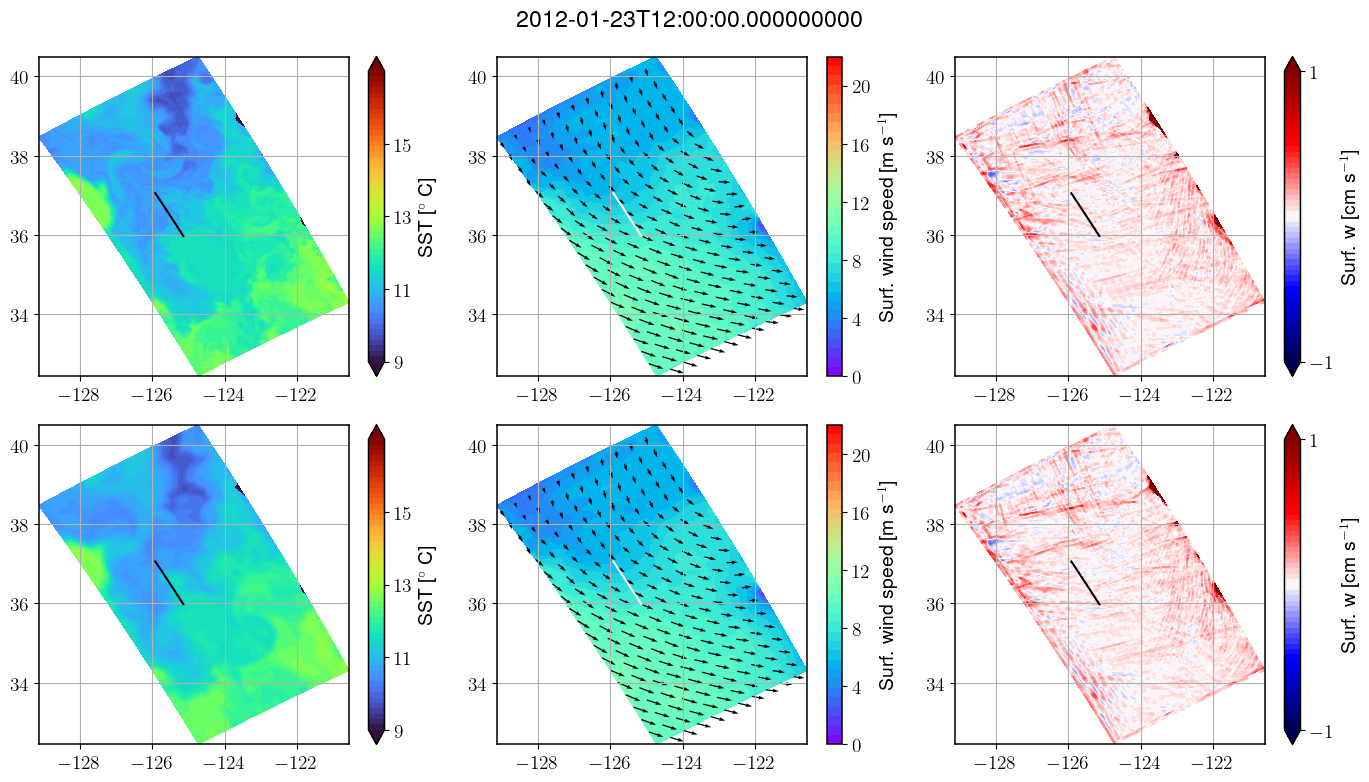

In [34]:
day_s=22

x_sta_lim=80
x_end_lim=81

y_sta_lim=180
y_end_lim=250

tmin=9
tmax=17

windmin=0
windmax=22

wmin=-1
wmax=1
plt.figure(figsize=(14,8))
plt.subplot(2,3,1)
# (sst_full-273.15)[1].plot(

c1=plt.contourf(lon_rho,lat_rho,(sst_full).isel(time_counter=day_s),levels=np.linspace(tmin,tmax,55),cmap='turbo',extend='both')
plt.colorbar(c1,ticks=np.arange(tmin,tmax,2),label=r'SST [$^{\circ}$ C]')
plt.plot(lon_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)),
         lat_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)),color='k')
plt.grid()


plt.title('')
plt.subplot(2,3,2)
dec=20
c2=plt.contourf(lon_rho,lat_rho,
    (np.sqrt(u_full.isel(lev_M=1,time_counter=day_s)**2 + v_full.isel(lev_M=1,time_counter=day_s).values**2)),
             levels=np.linspace(windmin,windmax,35),cmap='rainbow')
plt.plot(lon_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)),
         lat_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)),color='w')


plt.colorbar(c2,ticks=np.arange(windmin,windmax,4),label=r'Surf. wind speed [m s$^{-1}$]')

plt.quiver(lon_rho[::dec,::dec],lat_rho[::dec,::dec],
           u_full.isel(lev_M=1,time_counter=day_s)[::dec,::dec],
           v_full.isel(lev_M=1,time_counter=day_s)[::dec,::dec])
plt.title('')
plt.grid()


plt.subplot(2,3,4)
# (sst_full-273.15)[1].plot(
c3=plt.contourf(lon_rho,lat_rho,(sst_smth).isel(time_counter=day_s)
                ,levels=np.linspace(tmin,tmax,55),cmap='turbo',extend='both')
plt.colorbar(c3,ticks=np.arange(tmin,tmax,2),label=r'SST [$^{\circ}$ C]')

plt.plot(lon_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)),
         lat_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)),color='k')
plt.grid()

plt.subplot(2,3,5)
dec=20
c4=plt.contourf(lon_rho,lat_rho,
                (np.sqrt(u_smth.isel(lev_M=1,time_counter=day_s)**2 + v_smth.isel(lev_M=1,time_counter=day_s).values**2)),
             levels=np.linspace(windmin,windmax,35),cmap='rainbow')
plt.plot(lon_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)),
         lat_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)),color='w')
plt.colorbar(c4,ticks=np.arange(windmin,windmax,4),label=r'Surf. wind speed [m s$^{-1}$]')

plt.quiver(lon_rho[::dec,::dec],lat_rho[::dec,::dec],
           u_smth.isel(lev_M=1,time_counter=day_s)[::dec,::dec],
           v_smth.isel(lev_M=1,time_counter=day_s)[::dec,::dec])
plt.title('')
plt.grid()

plt.suptitle((sst_smth)['time_counter'][day_s].values)


plt.subplot(2,3,3)
c5=plt.contourf(lon_rho,lat_rho,
                (w_full).isel(lev_W=1,time_counter=day_s)*100,levels=np.linspace(wmin,wmax,55),cmap='seismic',extend='both')
plt.colorbar(c5,ticks=np.arange(wmin,wmax+2,2),label=r'Surf. w [cm s$^{-1}$]')
plt.plot(lon_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)),
         lat_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)),color='k')

plt.grid()

plt.subplot(2,3,6)
c6=plt.contourf(lon_rho,lat_rho,
                (w_smth).isel(lev_W=1,time_counter=day_s)*100,levels=np.linspace(wmin,wmax,55),cmap='seismic',extend='both')
plt.colorbar(c6,ticks=np.arange(wmin,wmax+2,2),label=r'Surf. w [cm s$^{-1}$]')
plt.plot(lon_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)),
         lat_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)),color='k')
plt.grid()


plt.tight_layout()

In [28]:
Altitude=((varfw['PH'] + varfw['PHB'])/9.8).isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim))#.squeeze()
Altitude_m=(Altitude[:,1:].data +  Altitude[:,:-1])/2


Altitude_smth=((vartw['PH'] + vartw['PHB'])/9.8).isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim))#.squeeze()
Altitude_m_smth=(Altitude_smth[:,1:].data +  Altitude_smth[:,:-1])/2

Text(0.5, 0, 'Distance [km]')

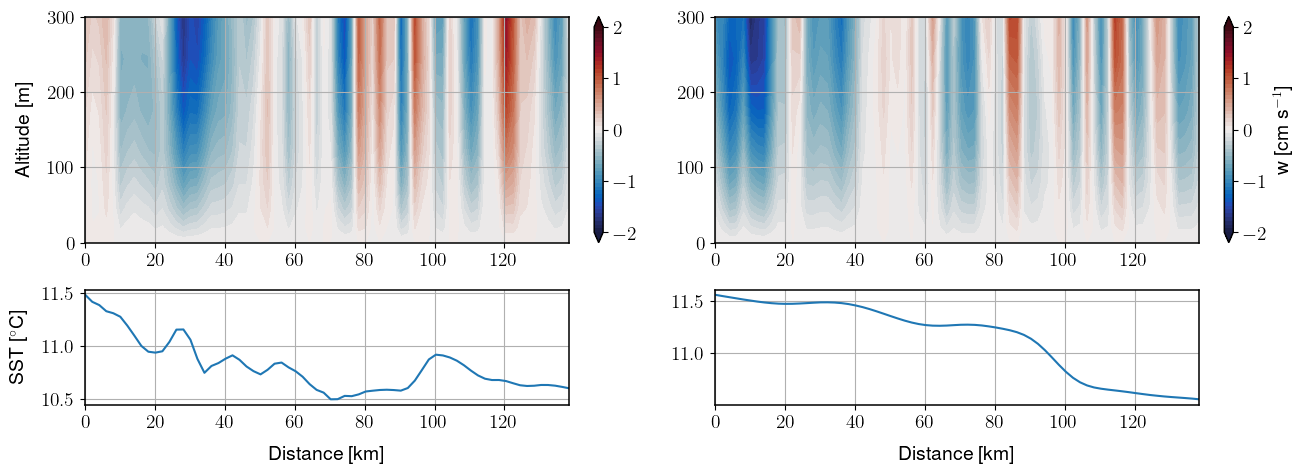

In [29]:
wmin=-2
wmax=2

sec_dist=Dist_Calc(lon=lon_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)),
                   lat=lat_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)))

ylim=300
fig2 = plt.figure(figsize=(15,6))
gs = GridSpec(100, 240, figure=fig2)
ax2 = fig2.add_subplot(gs[16:65,:100])

cb2=plt.contourf(sec_dist,
             Altitude.isel(time_counter=day_s).mean(['x_grid_M','y_grid_M']),
             w_full.isel(x_grid_M=slice(x_sta_lim,x_end_lim),
                         y_grid_M=slice(y_sta_lim,y_end_lim),
                         time_counter=day_s).squeeze()*100,
                 levels=np.linspace(wmin,wmax,55),cmap=cm.cm.balance,extend='both')
plt.grid()

cbar2=plt.colorbar(cb2,cax=plt.subplot(gs[16:65,105:107]),ticks=np.arange(wmin,wmax+1,1),
                   pad=1,shrink=0.002,orientation='vertical')
ax2.set_ylim(0,ylim)
ax2.set_xlim(0,sec_dist.max())
ax2.set_ylabel('Altitude [m]',labelpad=10)


ax3 = fig2.add_subplot(gs[75:,:100])

plt.plot(sec_dist,
             sst_full.isel(x_grid_M=slice(x_sta_lim,x_end_lim),
                         y_grid_M=slice(y_sta_lim,y_end_lim),
                         time_counter=day_s).squeeze())
plt.grid()
ax3.set_xlim(0,sec_dist.max())
ax3.set_xlabel('Distance [km]',labelpad=10)
ax3.set_ylabel(r'SST [$^{\circ}$C]',labelpad=10)

# ax3.set_ylim(sst_full.isel(x_grid_M=slice(x_sta_lim,x_end_lim),
#                          y_grid_M=slice(y_sta_lim,y_end_lim),time_counter=day_s).min(),
#                            sst_full.isel(x_grid_M=slice(x_sta_lim,x_end_lim),
#                          y_grid_M=slice(y_sta_lim,y_end_lim),time_counter=day_s).max())
ax4 = fig2.add_subplot(gs[16:65,130:230])

cb4=plt.contourf(sec_dist,
             Altitude.isel(time_counter=day_s).mean(['x_grid_M','y_grid_M']),
             w_smth.isel(x_grid_M=slice(x_sta_lim,x_end_lim),
                         y_grid_M=slice(y_sta_lim,y_end_lim),
                         time_counter=day_s).squeeze()*100,
             levels=np.linspace(wmin,wmax,55),cmap=cm.cm.balance,extend='both')
plt.grid()

cbar4=plt.colorbar(cb4,cax=plt.subplot(gs[16:65,235:237]),ticks=np.arange(wmin,wmax+1,1),
                   pad=1,shrink=0.002,orientation='vertical',label=r'w [cm s$^{-1}$]')

ax4.set_ylim(0,ylim)
ax4.set_xlim(0,sec_dist.max())



ax5 = fig2.add_subplot(gs[75:,130:230])

plt.plot(sec_dist,
             sst_smth.isel(x_grid_M=slice(x_sta_lim,x_end_lim),
                         y_grid_M=slice(y_sta_lim,y_end_lim),
                         time_counter=day_s).squeeze())
plt.grid()
# ax5.set_ylim(sst_full.isel(x_grid_M=slice(x_sta_lim,x_end_lim),
#                          y_grid_M=slice(y_sta_lim,y_end_lim),time_counter=day_s).min(),
#                            sst_full.isel(x_grid_M=slice(x_sta_lim,x_end_lim),
#                          y_grid_M=slice(y_sta_lim,y_end_lim),time_counter=day_s).max())

ax5.set_xlim(0,sec_dist.max())
ax5.set_xlabel('Distance [km]',labelpad=10)

### Averaged plots

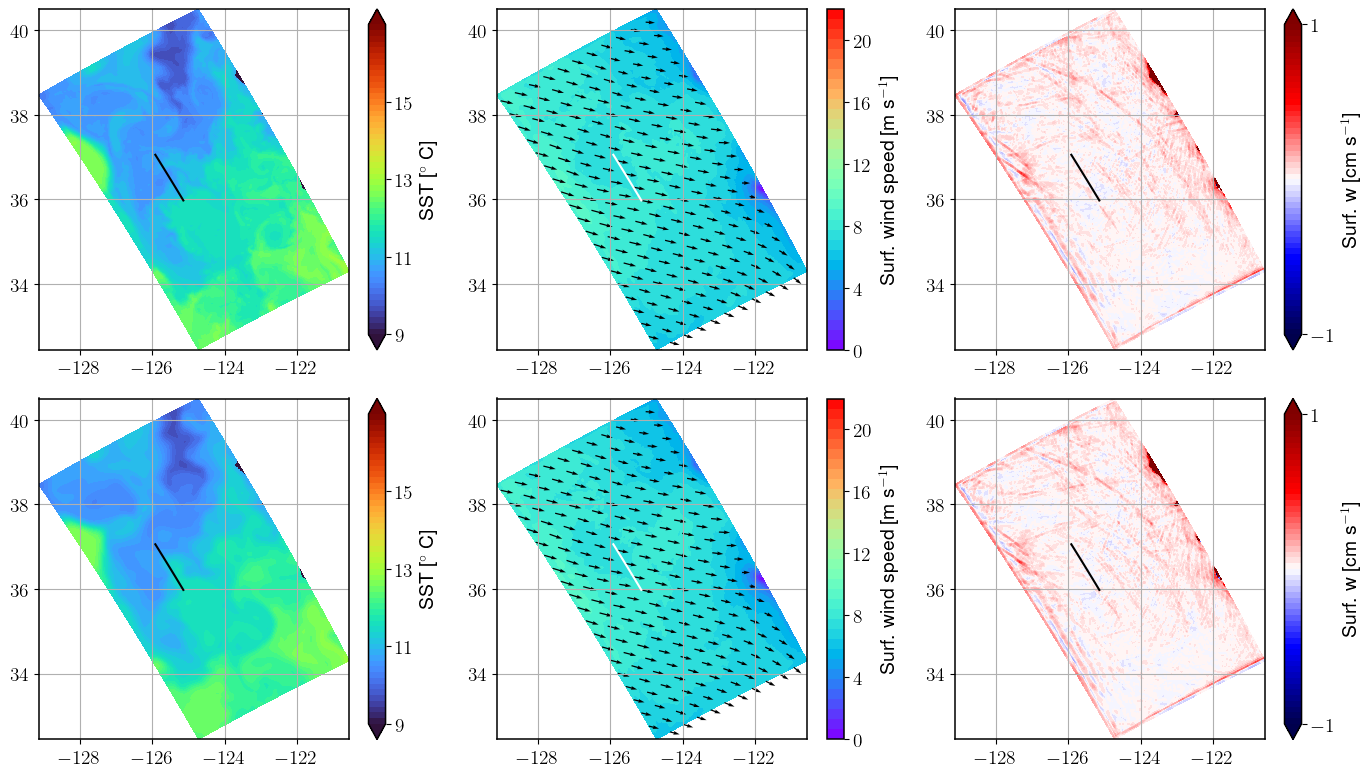

In [59]:
day_s=slice(20,23)

x_sta_lim=80
x_end_lim=81

y_sta_lim=180
y_end_lim=250

tmin=9
tmax=17

windmin=0
windmax=22

wmin=-1
wmax=1
plt.figure(figsize=(14,8))
plt.subplot(2,3,1)
# (sst_full-273.15)[1].plot(

c1=plt.contourf(lon_rho,lat_rho,(sst_full).isel(time_counter=day_s).mean('time_counter'),
                levels=np.linspace(tmin,tmax,55),cmap='turbo',extend='both')
plt.colorbar(c1,ticks=np.arange(tmin,tmax,2),label=r'SST [$^{\circ}$ C]')
plt.plot(lon_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)),
         lat_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)),color='k')
plt.grid()


plt.title('')
plt.subplot(2,3,2)
dec=20
c2=plt.contourf(lon_rho,lat_rho,
    (np.sqrt(u_full.isel(lev_M=1,time_counter=day_s).mean('time_counter')**2 +
             v_full.isel(lev_M=1,time_counter=day_s).mean('time_counter').values**2)),
             levels=np.linspace(windmin,windmax,35),cmap='rainbow')
plt.plot(lon_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)),
         lat_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)),color='w')


plt.colorbar(c2,ticks=np.arange(windmin,windmax,4),label=r'Surf. wind speed [m s$^{-1}$]')

plt.quiver(lon_rho[::dec,::dec],lat_rho[::dec,::dec],
           u_full.isel(lev_M=1,time_counter=day_s).mean('time_counter')[::dec,::dec],
           v_full.isel(lev_M=1,time_counter=day_s).mean('time_counter')[::dec,::dec])
plt.title('')
plt.grid()


plt.subplot(2,3,4)
# (sst_full-273.15)[1].plot(
c3=plt.contourf(lon_rho,lat_rho,(sst_smth).isel(time_counter=day_s).mean('time_counter')
                ,levels=np.linspace(tmin,tmax,55),cmap='turbo',extend='both')
plt.colorbar(c3,ticks=np.arange(tmin,tmax,2),label=r'SST [$^{\circ}$ C]')

plt.plot(lon_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)),
         lat_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)),color='k')
plt.grid()

plt.subplot(2,3,5)
dec=20
c4=plt.contourf(lon_rho,lat_rho,
     (np.sqrt(u_smth.isel(lev_M=1,time_counter=day_s).mean('time_counter')**2 +
              v_smth.isel(lev_M=1,time_counter=day_s).mean('time_counter').values**2)),
             levels=np.linspace(windmin,windmax,35),cmap='rainbow')
plt.plot(lon_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)),
         lat_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)),color='w')
plt.colorbar(c4,ticks=np.arange(windmin,windmax,4),label=r'Surf. wind speed [m s$^{-1}$]')

plt.quiver(lon_rho[::dec,::dec],lat_rho[::dec,::dec],
           u_smth.isel(lev_M=1,time_counter=day_s).mean('time_counter')[::dec,::dec],
           v_smth.isel(lev_M=1,time_counter=day_s).mean('time_counter')[::dec,::dec])
plt.title('')
plt.grid()

# plt.suptitle((sst_smth)['time_counter'].isel(time_counter=day_s).mean('time_counter').values)


plt.subplot(2,3,3)
c5=plt.contourf(lon_rho,lat_rho,
                (w_full).isel(lev_W=1,time_counter=day_s).mean('time_counter')*100,levels=np.linspace(wmin,wmax,55),cmap='seismic',extend='both')
plt.colorbar(c5,ticks=np.arange(wmin,wmax+2,2),label=r'Surf. w [cm s$^{-1}$]')
plt.plot(lon_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)),
         lat_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)),color='k')

plt.grid()

plt.subplot(2,3,6)
c6=plt.contourf(lon_rho,lat_rho,
                (w_smth).isel(lev_W=1,time_counter=day_s).mean('time_counter')*100,levels=np.linspace(wmin,wmax,55),cmap='seismic',extend='both')
plt.colorbar(c6,ticks=np.arange(wmin,wmax+2,2),label=r'Surf. w [cm s$^{-1}$]')
plt.plot(lon_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)),
         lat_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)),color='k')
plt.grid()


plt.tight_layout()

In [60]:
Altitude=((varfw['PH'] + varfw['PHB'])/9.8).isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim))#.squeeze()
Altitude_m=(Altitude[:,1:].data +  Altitude[:,:-1])/2


Altitude_smth=((vartw['PH'] + vartw['PHB'])/9.8).isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim))#.squeeze()
Altitude_m_smth=(Altitude_smth[:,1:].data +  Altitude_smth[:,:-1])/2

Text(0.5, 0, 'Distance [km]')

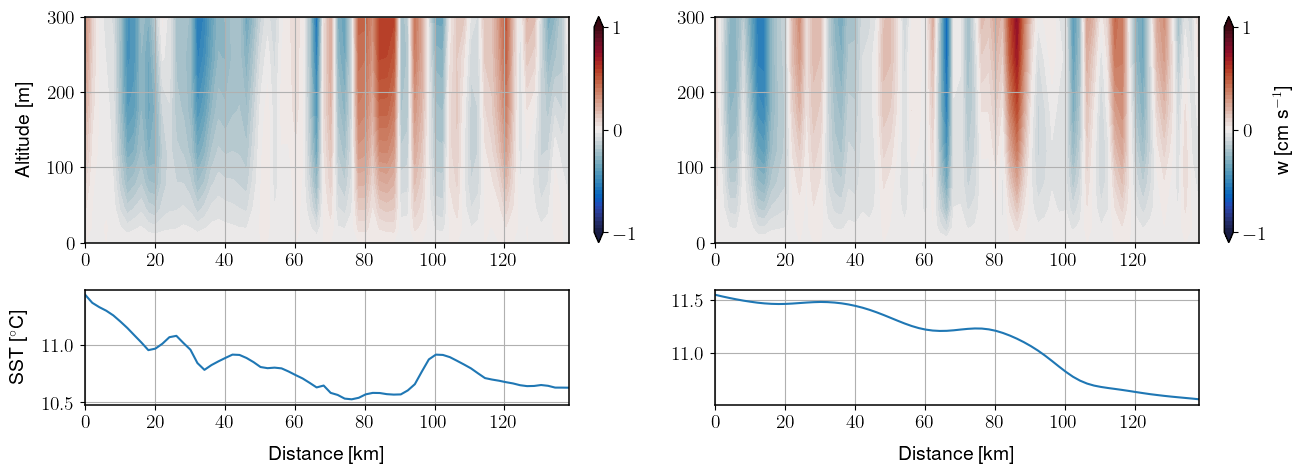

In [61]:
wmin=-1
wmax=1

sec_dist=Dist_Calc(lon=lon_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)),
                   lat=lat_rho.isel(x_grid_M=slice(x_sta_lim,x_end_lim),y_grid_M=slice(y_sta_lim,y_end_lim)))

ylim=300
fig2 = plt.figure(figsize=(15,6))
gs = GridSpec(100, 240, figure=fig2)
ax2 = fig2.add_subplot(gs[16:65,:100])

cb2=plt.contourf(sec_dist,
             Altitude.isel(time_counter=day_s).mean(['x_grid_M','y_grid_M']).mean('time_counter'),
             w_full.isel(x_grid_M=slice(x_sta_lim,x_end_lim),
                         y_grid_M=slice(y_sta_lim,y_end_lim),
                         time_counter=day_s).mean('time_counter').squeeze()*100,
                 levels=np.linspace(wmin,wmax,55),cmap=cm.cm.balance,extend='both')
plt.grid()

cbar2=plt.colorbar(cb2,cax=plt.subplot(gs[16:65,105:107]),ticks=np.arange(wmin,wmax+1,1),
                   pad=1,shrink=0.002,orientation='vertical')
ax2.set_ylim(0,ylim)
ax2.set_xlim(0,sec_dist.max())
ax2.set_ylabel('Altitude [m]',labelpad=10)


ax3 = fig2.add_subplot(gs[75:,:100])

plt.plot(sec_dist,
             sst_full.isel(x_grid_M=slice(x_sta_lim,x_end_lim),
                         y_grid_M=slice(y_sta_lim,y_end_lim),
                         time_counter=day_s).mean('time_counter').squeeze())
plt.grid()
ax3.set_xlim(0,sec_dist.max())
ax3.set_xlabel('Distance [km]',labelpad=10)
ax3.set_ylabel(r'SST [$^{\circ}$C]',labelpad=10)

# ax3.set_ylim(sst_full.isel(x_grid_M=slice(x_sta_lim,x_end_lim),
#                          y_grid_M=slice(y_sta_lim,y_end_lim),time_counter=day_s).min(),
#                            sst_full.isel(x_grid_M=slice(x_sta_lim,x_end_lim),
#                          y_grid_M=slice(y_sta_lim,y_end_lim),time_counter=day_s).max())
ax4 = fig2.add_subplot(gs[16:65,130:230])

cb4=plt.contourf(sec_dist,
             Altitude.isel(time_counter=day_s).mean(['x_grid_M','y_grid_M']).mean('time_counter'),
             w_smth.isel(x_grid_M=slice(x_sta_lim,x_end_lim),
                         y_grid_M=slice(y_sta_lim,y_end_lim),
                         time_counter=day_s).squeeze().mean('time_counter')*100,
             levels=np.linspace(wmin,wmax,55),cmap=cm.cm.balance,extend='both')
plt.grid()

cbar4=plt.colorbar(cb4,cax=plt.subplot(gs[16:65,235:237]),ticks=np.arange(wmin,wmax+1,1),
                   pad=1,shrink=0.002,orientation='vertical',label=r'w [cm s$^{-1}$]')

ax4.set_ylim(0,ylim)
ax4.set_xlim(0,sec_dist.max())



ax5 = fig2.add_subplot(gs[75:,130:230])

plt.plot(sec_dist,
             sst_smth.isel(x_grid_M=slice(x_sta_lim,x_end_lim),
                         y_grid_M=slice(y_sta_lim,y_end_lim),
                         time_counter=day_s).squeeze().mean('time_counter'))
plt.grid()
# ax5.set_ylim(sst_full.isel(x_grid_M=slice(x_sta_lim,x_end_lim),
#                          y_grid_M=slice(y_sta_lim,y_end_lim),time_counter=day_s).min(),
#                            sst_full.isel(x_grid_M=slice(x_sta_lim,x_end_lim),
#                          y_grid_M=slice(y_sta_lim,y_end_lim),time_counter=day_s).max())

ax5.set_xlim(0,sec_dist.max())
ax5.set_xlabel('Distance [km]',labelpad=10)